[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/05_machine_learning/A1_pytorch_foundations.ipynb)

> 📎 **Appendix notebook — reference style.** This is one of the optional appendices (see `README.md`). Unlike the main course notebooks, appendices are written as a demo / reference: they focus on *seeing* a library at work rather than on interactive exercises. You won't find the full Solution / Debug-me / Self-assessment scaffolding here. Each appendix is built to run end-to-end *without* the optional library — it falls back to a small built-in stand-in (or skips the library-specific cells), so you can read and run it offline. Install the optional library (see the **Install** section below) to swap the stand-in for the real thing.

---
# 📓 Notebook A1 (ML) — PyTorch Foundations

> **Module:** Machine Learning · **Type:** Appendix · **Estimated time:** 60–90 min · **Difficulty:** Intermediate → Advanced

Modules 5 and 8 cover *classical* ML and prompt-driven *AI engineering*. This three-notebook PyTorch mini-track sits between them: when scikit-learn isn't enough and you need to train your own neural network — for tabular regression, image classification, sequence modelling, or fine-tuning a small transformer — PyTorch is the de-facto tool.

This first notebook gives you the **non-negotiable foundations**: tensors, autograd, modules, optimisers, training loops. By the end you'll train an MLP on tabular data and understand every line.

---

## 🎯 Learning objectives
- Manipulate `torch.Tensor` with confidence (shapes, devices, dtypes, autograd).
- Build models with `nn.Module` and train them with the canonical training loop.
- Diagnose and avoid the four classic bugs: NaN loss, frozen gradients, leaked test data, wrong device.
- Train a small MLP on a real tabular dataset and beat a logistic-regression baseline.

## ✅ Prerequisites
- Notebooks 1–9 (Python fluency, NumPy, and plotting basics).
- Notebook 17 (`17_sklearn_basics.ipynb`) for the scikit-learn baseline.
- Optional: Notebook 19 (feature engineering).

## 📦 Install

```bash
pip install torch --index-url https://download.pytorch.org/whl/cpu     # CPU-only build, ~250 MB
# Or for a CUDA-enabled GPU:
# pip install torch --index-url https://download.pytorch.org/whl/cu121
```


## 1. Smoke test — is PyTorch available?

The whole notebook checks `HAS_TORCH` and skips runtime cells gracefully if torch isn't installed. The *code is still there* for you to read.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    HAS_TORCH = True
    print(f"PyTorch {torch.__version__}  ·  CUDA available: {torch.cuda.is_available()}")
except Exception as e:
    HAS_TORCH = False
    print("PyTorch not installed —", e)
    print("Install with:  pip install torch --index-url https://download.pytorch.org/whl/cpu")


/Users/christophweisser/Desktop/Coding/Python for AI-Driven Automation and Business Data Science/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


PyTorch 2.12.0  ·  CUDA available: False


## 2. Tensors — the only data structure you need

A `torch.Tensor` is a multi-dimensional array that *also* tracks gradients. Three things you'll do constantly:


In [2]:
if HAS_TORCH:
    # (a) Construction
    a = torch.zeros(2, 3)
    b = torch.randn(2, 3)
    c = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
    print("a:", a.shape, a.dtype, "·  b:", b.shape, "·  c:", c.tolist())

a: torch.Size([2, 3]) torch.float32 ·  b: torch.Size([2, 3]) ·  c: [[1.0, 2.0], [3.0, 4.0]]


In [3]:
if HAS_TORCH:
    # (b) Shape gymnastics — view / reshape / unsqueeze / transpose
    x = torch.arange(12).reshape(3, 4)              # 3×4
    print("view(2,6):", x.view(2, 6).shape)
    print("unsqueeze(0):", x.unsqueeze(0).shape)   # 1×3×4 (add batch axis)
    print("permute(1,0):", x.permute(1, 0).shape)  # 4×3

view(2,6): torch.Size([2, 6])
unsqueeze(0): torch.Size([1, 3, 4])
permute(1,0): torch.Size([4, 3])


In [4]:
if HAS_TORCH:
    # (c) Device & dtype
    x = torch.randn(3, 3, dtype=torch.float32)
    x_cpu = x.to("cpu")
    # x_gpu = x.to("cuda")   # only if CUDA is available
    print("device:", x_cpu.device, "dtype:", x_cpu.dtype)

device: cpu dtype: torch.float32


## 3. Autograd in one minute

Set `requires_grad=True` and PyTorch records every operation. Call `.backward()` to fill `.grad` with $\partial L / \partial \text{param}$ — that's all it takes.


In [5]:
if HAS_TORCH:
    x = torch.tensor(2.0, requires_grad=True)
    y = x ** 3 + 2 * x + 1     # y = x³ + 2x + 1
    y.backward()
    print("y =", y.item())
    print("dy/dx at x=2.0 :", x.grad.item(), "(expected 3·4 + 2 = 14)")

    # Gradients accumulate — always zero them before the next backward:
    x.grad.zero_()


y = 13.0
dy/dx at x=2.0 : 14.0 (expected 3·4 + 2 = 14)


**Why does this matter?** Every neural-network training loop is just `(compute loss) → loss.backward() → optimiser.step()`. Autograd computes *all* the gradients for *all* the parameters automatically, no matter how complex the model.

⚠️ **Pitfall #1 — gradients accumulate.** If you forget `optimizer.zero_grad()`, your gradients from the previous step get added in. The model will slowly diverge and you'll spend an afternoon staring at it.


### 🔬 What actually happens when you call `.backward()`?

The cell above looks like magic: you never wrote a single derivative, yet `x.grad` came out *exactly* right. Here is the whole trick, with no magic left in it.

The moment a tensor carries `requires_grad=True`, PyTorch starts **secretly recording** every operation you do to it into a hidden graph — the *computation graph*. Each node remembers two things: the operation that made it, and how to compute its **local derivative**. Take `y = x**2 + 2*x` with `x = 3.0`:

**Step 1 — forward pass.** As you build `y`, torch records the graph left-to-right and computes the value:

```text
   x = 3.0  (leaf, requires_grad=True)
     │
     ├──────────────┐
     ▼              ▼
  [ x**2 ]       [ 2*x ]          ← each op is RECORDED as a node
   = 9.0          = 6.0             (it also stores its local derivative)
     │              │
     └──────┬───────┘
            ▼
         [ a + b ]
          y = 15.0   ← y "knows" the entire history that built it
```

**Step 2 — backward pass.** `y.backward()` walks that same graph **right-to-left**, multiplying local derivatives together via the **chain rule**, and *deposits* the final number into the leaf's `.grad`:

```text
         y         seed:  dy/dy = 1
         │
   ┌─────┴─────┐
   ▼           ▼
 [x**2]      [2*x]
 d/dx=2x     d/dx=2
 = 2·3 = 6   = 2
   │           │
   └─────┬─────┘   add the two paths (sum rule)
         ▼
       x.grad  =  6 + 2  =  8       ✅  matches 2x+2 = 8
```

You never wrote `2*x + 2`. Torch derived it by replaying the recorded graph backward. That is *autograd* — automatic differentiation.

### Leaf vs. result — who gets a `.grad`?

Two kinds of tensors live in that graph, and they behave differently. Knowing which is which removes 90% of "why is my `.grad` None?" confusion:

| | **Leaf** (e.g. `x`) | **Result** (e.g. `y`) |
|---|---|---|
| How it's made | You created it directly with `requires_grad=True` | Produced by an operation on other tensors |
| `.is_leaf` | `True` | `False` |
| `.grad_fn` | `None` (nothing made it) | a function node, e.g. `<AddBackward0>` |
| Gets `.grad` filled? | **Yes** — this is what you optimise | No (by default it's freed to save memory) |
| Role in training | A **parameter / weight** | An **intermediate value** or the **loss** |

The takeaway: `.backward()` flows gradients *back to the leaves*. In a real model the leaves are your weights — exactly the things the optimiser will nudge. The proof cell below prints these attributes so you can see the difference with your own eyes.

In [6]:
# 🧪 PROOF #1 — autograd's gradient == the hand-derived derivative.
# Self-contained: tiny CPU tensors, no model, runs offline.
if HAS_TORCH:
    x = torch.tensor(3.0, requires_grad=True)   # a LEAF
    y = x**2 + 2*x                               # a RESULT (built by ops)

    # Inspect the graph BEFORE calling backward:
    print("x.is_leaf  :", x.is_leaf,  "| x.grad_fn:", x.grad_fn)   # leaf  -> None
    print("y.is_leaf  :", y.is_leaf,  "| y.grad_fn:", y.grad_fn)   # result-> AddBackward
    print("x.grad before backward:", x.grad)                       # None — not computed yet

    y.backward()            # walk the graph backward, fill leaf .grad via chain rule

    autograd_grad = x.grad.item()
    hand_grad     = 2 * 3.0 + 2          # derivative of x²+2x is 2x+2, at x=3 -> 8
    print(f"\nautograd x.grad = {autograd_grad}")
    print(f"hand 2x+2       = {hand_grad}")
    assert autograd_grad == hand_grad, "autograd disagreed with calculus!"
    print("✅ autograd matches the calculus exactly.")
else:
    print("PyTorch not available — skipping.")


x.is_leaf  : True | x.grad_fn: None
y.is_leaf  : False | y.grad_fn: <AddBackward0 object at 0x11acd5270>
x.grad before backward: None

autograd x.grad = 8.0
hand 2x+2       = 8.0
✅ autograd matches the calculus exactly.


### One gradient-descent step — by hand, then why `zero_grad`

A gradient tells you the **uphill** direction of the loss. To *minimise*, you step a little in the **opposite** direction. That one update — done with a real optimiser later — is just:

```text
new_value  =  old_value  −  learning_rate × gradient
```

We do it by hand below to demystify `optimizer.step()`. Two subtleties matter:

1. **`with torch.no_grad():`** — the weight update is *not* part of the math we're differentiating, so we tell torch to stop recording. Without it, torch would try to track the update itself and complain.
2. **`x.grad.zero_()`** — gradients **accumulate** (they `+=`, never reset). PyTorch does this on purpose (it's handy for splitting a batch), but it means *you* must wipe `.grad` to zero before the next `.backward()`. Forget it, and step 2's gradient is secretly *step 1 + step 2* — your training slowly goes haywire.

The proof cell runs two steps and shows that **without** zeroing, the gradient doubles.

In [7]:
# 🧪 PROOF #2 — one gradient-descent step, and why grads must be zeroed.
# Minimise f(x) = x²  (minimum at x=0).  df/dx = 2x.  Self-contained, offline.
if HAS_TORCH:
    lr = 0.1
    x = torch.tensor(3.0, requires_grad=True)

    # ----- one clean GD step -----
    loss = x**2
    loss.backward()                       # x.grad = 2*3 = 6
    print(f"start x = {x.item():.4f},  grad = {x.grad.item():.4f}")
    with torch.no_grad():                 # don't record the weight update
        x -= lr * x.grad                  # x = 3 - 0.1*6 = 2.4  (moved toward 0 ✅)
    print(f"after step x = {x.item():.4f}   (closer to the minimum at 0)\n")

    # ----- demonstrate accumulation: backward TWICE without zeroing -----
    z = torch.tensor(1.0, requires_grad=True)
    (z**2).backward()
    print("after 1st backward, z.grad =", z.grad.item(), "(expected 2)")
    (z**2).backward()                     # NOT zeroed -> grads ADD UP
    print("after 2nd backward, z.grad =", z.grad.item(), "(expected 2, got 4 — accumulated!)")
    z.grad.zero_()                        # THE FIX
    (z**2).backward()
    print("after zero_() + backward, z.grad =", z.grad.item(), "(expected 2 — clean ✅)")
else:
    print("PyTorch not available — skipping.")


start x = 3.0000,  grad = 6.0000
after step x = 2.4000   (closer to the minimum at 0)

after 1st backward, z.grad = 2.0 (expected 2)
after 2nd backward, z.grad = 4.0 (expected 2, got 4 — accumulated!)
after zero_() + backward, z.grad = 2.0 (expected 2 — clean ✅)


> 🧠 **The mental model to keep.** Torch **records** your forward computation as a graph; `.backward()` **replays it in reverse** with the chain rule to get every gradient automatically. That's why the entire training loop is always the same four beats:
>
> ```text
>   forward  →  backward  →  step  →  zero_grad   (repeat)
>   compute     fill .grad   nudge    wipe .grad
>   the loss    via graph    weights  for next time
> ```
>
> 🎯 Every line of Section 5's training loop maps onto exactly one of these four beats. Once you see that, no PyTorch loop will ever look mysterious again.

> ⚠️ **Re-running this section is safe.** Every proof cell creates its *own* fresh tensors and zeroes any grad it accumulates, so you can run them in any order, any number of times, and always get the same numbers.

---

### ✋ Quick exercise (~2 min) — One gradient step by hand

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You're tuning a single price-sensitivity weight `w` to minimise a cost `L = (w - 5)²`. Starting from `w = 8.0`, use **autograd** to get `dL/dw`, then take **one** gradient-descent step with learning rate `0.1`. What's the new `w`?

```python
w = torch.tensor(8.0, requires_grad=True)
# L = (w - 5)**2  →  backward()  →  step against the gradient
```

In [8]:
# ✍️ Your turn 👇
if HAS_TORCH:
    w = torch.tensor(8.0, requires_grad=True)
    # 1) compute L = (w - 5)**2 and call .backward()
    # 2) print the gradient w.grad
    # 3) take ONE gradient-descent step (lr=0.1) inside torch.no_grad(), then print the new w
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    w = torch.tensor(8.0, requires_grad=True)
    L = (w - 5) ** 2
    L.backward()
    print("grad:", w.grad.item())        # 2*(8-5) = 6.0
    with torch.no_grad():
        w -= 0.1 * w.grad                 # 8 - 0.1*6 = 7.4
    print("new w:", w.item())            # 7.4
```

The gradient of `(w-5)²` is `2(w-5) = 6` at `w=8`. Stepping *against* the gradient with `lr=0.1` moves `w` from 8 toward the minimum at 5, landing at 7.4. The `torch.no_grad()` block keeps the weight update out of the graph.
</details>

## 4. A model in 6 lines — `nn.Module`

Subclass `nn.Module`, register layers in `__init__`, write the forward pass. That's it.


In [9]:
if HAS_TORCH:
    class MLP(nn.Module):
        def __init__(self, in_dim, hidden, out_dim, p_drop=0.1):
            super().__init__()
            self.fc1  = nn.Linear(in_dim, hidden)
            self.fc2  = nn.Linear(hidden, hidden)
            self.fc3  = nn.Linear(hidden, out_dim)
            self.drop = nn.Dropout(p_drop)
        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = self.drop(F.relu(self.fc2(x)))
            return self.fc3(x)

    model = MLP(in_dim=10, hidden=64, out_dim=1)
    print(model)
    print("Parameter count:", sum(p.numel() for p in model.parameters()))


MLP(
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (drop): Dropout(p=0.1, inplace=False)
)
Parameter count: 4929


**Mental model:** an `nn.Module` is a *registry* — every `nn.Linear` you assign to `self.x` automatically appears in `.parameters()`. The optimiser updates exactly what's in that list.

💡 **Tip.** Print the model before training — the architecture summary catches at least 1 in 3 bugs (wrong dim, missing activation, accidental `nn.Identity` left in).


## 5. The canonical training loop

Memorise this skeleton. Every PyTorch training script you ever read is a variation on it.


In [10]:
if HAS_TORCH:
    # Tiny synthetic regression task: y = 2*x0 - 3*x1 + 0.5*x2 + noise
    torch.manual_seed(0)
    N, D = 1000, 3
    X = torch.randn(N, D)
    y = (2*X[:,0] - 3*X[:,1] + 0.5*X[:,2] + 0.1*torch.randn(N)).unsqueeze(1)

    # Train/val split
    n_tr = int(0.8 * N)
    X_tr, X_va = X[:n_tr], X[n_tr:]
    y_tr, y_va = y[:n_tr], y[n_tr:]

In [11]:
if HAS_TORCH:
    model     = MLP(in_dim=D, hidden=32, out_dim=1, p_drop=0.0)
    optim     = torch.optim.Adam(model.parameters(), lr=1e-2)
    loss_fn   = nn.MSELoss()

In [12]:
if HAS_TORCH:
    history = []
    for epoch in range(200):
        # (1) forward + loss
        model.train()
        pred = model(X_tr)
        loss = loss_fn(pred, y_tr)
        # (2) backward
        optim.zero_grad()
        loss.backward()
        # (3) step
        optim.step()
        # (4) eval
        if epoch % 20 == 0 or epoch == 199:
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(X_va), y_va).item()
            history.append((epoch, loss.item(), val_loss))

    for e, tr, va in history:
        print(f"epoch {e:3d}  train MSE {tr:.4f}  val MSE {va:.4f}")

epoch   0  train MSE 12.9160  val MSE 13.3276
epoch  20  train MSE 1.1693  val MSE 0.6801
epoch  40  train MSE 0.1985  val MSE 0.2013
epoch  60  train MSE 0.0435  val MSE 0.0594
epoch  80  train MSE 0.0221  val MSE 0.0274
epoch 100  train MSE 0.0163  val MSE 0.0220
epoch 120  train MSE 0.0147  val MSE 0.0202
epoch 140  train MSE 0.0136  val MSE 0.0192
epoch 160  train MSE 0.0128  val MSE 0.0184
epoch 180  train MSE 0.0122  val MSE 0.0178
epoch 199  train MSE 0.0117  val MSE 0.0171


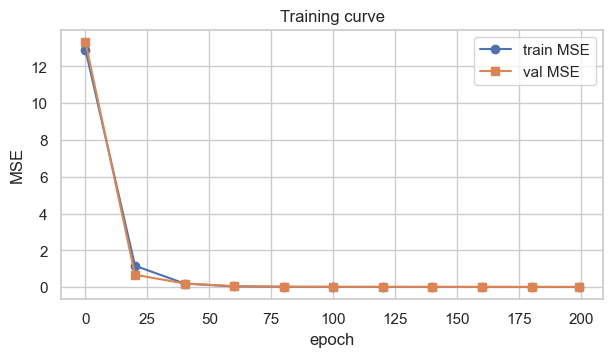

In [13]:
if HAS_TORCH:
    h = np.array(history)
    plt.figure(figsize=(7, 3.5))
    plt.plot(h[:,0], h[:,1], "o-", label="train MSE")
    plt.plot(h[:,0], h[:,2], "s-", label="val MSE")
    plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend(); plt.title("Training curve")
    plt.show()


**Read each block again.** Forward → loss → `zero_grad` → `backward` → `step`. The order matters: zero out, then accumulate fresh gradients, then step. Skipping `model.eval()` during validation leaves dropout *on*, which hurts your reported numbers.

⚠️ **Pitfall #2 — `model.train()` vs `model.eval()`.** These toggle dropout & batch-norm running statistics. Forget the switch and your validation loss becomes noisy/biased.


---

### ✋ Quick exercise (~2 min) — Predict the shape & parameter count

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Using the `MLP` class from §4, build a churn model with **8 input features, hidden=16, out_dim=1**. *Before* running anything, predict (a) the output shape for a batch of **5** customers, and (b) the total parameter count. Then verify with code.

```python
m = MLP(in_dim=8, hidden=16, out_dim=1)
x = torch.randn(5, 8)
```

In [14]:
# ✍️ Your turn 👇
if HAS_TORCH:
    m = MLP(in_dim=8, hidden=16, out_dim=1)
    x = torch.randn(5, 8)
    # First WRITE DOWN your prediction, then verify:
    #   (a) print m(x).shape
    #   (b) print the total parameter count
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    m = MLP(in_dim=8, hidden=16, out_dim=1)
    x = torch.randn(5, 8)
    print(m(x).shape)                                 # torch.Size([5, 1])
    print(sum(p.numel() for p in m.parameters()))     # 433
```

The batch dimension (5) is preserved and the last dim becomes `out_dim=1`, so the output is `[5, 1]`. Params: fc1 `8*16+16=144`, fc2 `16*16+16=272`, fc3 `16*1+1=17` → **433** (Dropout adds none).
</details>

## 6. DataLoaders — batching done right

For real datasets you can't feed everything at once. `Dataset` + `DataLoader` give you mini-batches, shuffling, and parallel loading.


In [15]:
if HAS_TORCH:
    from torch.utils.data import TensorDataset, DataLoader

    ds_tr = TensorDataset(X_tr, y_tr)
    ds_va = TensorDataset(X_va, y_va)
    dl_tr = DataLoader(ds_tr, batch_size=64, shuffle=True)
    dl_va = DataLoader(ds_va, batch_size=256)

    model = MLP(D, 32, 1, p_drop=0.0)
    optim = torch.optim.Adam(model.parameters(), lr=1e-2)
    loss_fn = nn.MSELoss()

    for epoch in range(20):
        model.train()
        for xb, yb in dl_tr:
            optim.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optim.step()
    model.eval()
    with torch.no_grad():
        val = sum(loss_fn(model(xb), yb).item() * xb.size(0) for xb, yb in dl_va) / len(ds_va)
    print(f"final val MSE after mini-batch training: {val:.4f}")


final val MSE after mini-batch training: 0.0169


For pandas/NumPy tabular data, the easiest pattern is `TensorDataset(torch.from_numpy(X_np).float(), torch.from_numpy(y_np).float())`. For images use `torchvision.datasets.ImageFolder`; for text, `torch.utils.data.Dataset` subclass that tokenises on the fly.


## 7. A real tabular dataset — beat the logistic baseline

We'll use scikit-learn's `make_classification` so the notebook runs anywhere. The pattern transfers directly to your own CSV: load → scale → tensors → DataLoader → train.


In [16]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

X, y = make_classification(n_samples=2000, n_features=20, n_informative=10,
                           n_redundant=4, n_classes=2, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

# (1) Sklearn baseline
clf = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr)
p_te = clf.predict_proba(X_te_s)[:, 1]
print(f"Logistic baseline  ·  acc={accuracy_score(y_te, p_te > 0.5):.3f}  AUC={roc_auc_score(y_te, p_te):.3f}")


Logistic baseline  ·  acc=0.764  AUC=0.848


In [17]:
if HAS_TORCH:
    from torch.utils.data import TensorDataset, DataLoader

    def to_tensor(a, dtype=torch.float32): return torch.from_numpy(a).to(dtype)
    Xtr = to_tensor(X_tr_s); ytr = to_tensor(y_tr, torch.float32).unsqueeze(1)
    Xte = to_tensor(X_te_s); yte = to_tensor(y_te, torch.float32).unsqueeze(1)

    dl_tr = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

In [18]:
if HAS_TORCH:
    class TabularMLP(nn.Module):
        def __init__(self, in_dim, hidden=64, p_drop=0.2):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(p_drop),
                nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p_drop),
                nn.Linear(hidden, 1),
            )
        def forward(self, x): return self.net(x)

    model = TabularMLP(in_dim=Xtr.shape[1])
    optim = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss()

In [19]:
if HAS_TORCH:
    for epoch in range(40):
        model.train()
        for xb, yb in dl_tr:
            optim.zero_grad()
            loss = loss_fn(model(xb), yb); loss.backward(); optim.step()
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(Xte)).squeeze().numpy()
    print(f"MLP  ·  acc={accuracy_score(y_te, probs > 0.5):.3f}  AUC={roc_auc_score(y_te, probs):.3f}")

MLP  ·  acc=0.948  AUC=0.985


**Beat the baseline — visualised.** Side by side, does the MLP actually clear the logistic bar on both accuracy and AUC?

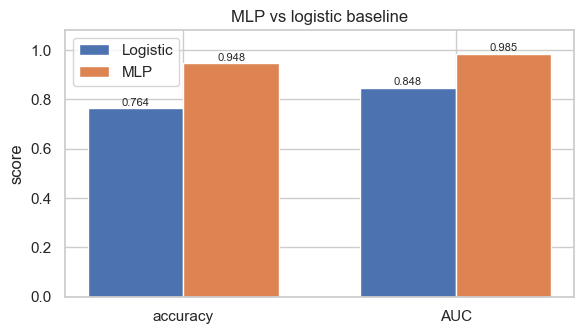

In [20]:
if HAS_TORCH:
    log_acc = accuracy_score(y_te, p_te > 0.5)
    log_auc = roc_auc_score(y_te, p_te)
    mlp_acc = accuracy_score(y_te, probs > 0.5)
    mlp_auc = roc_auc_score(y_te, probs)

    xpos = np.arange(2)                       # accuracy, AUC
    w = 0.35
    plt.figure(figsize=(6, 3.5))
    plt.bar(xpos - w/2, [log_acc, log_auc], w, label="Logistic")
    plt.bar(xpos + w/2, [mlp_acc, mlp_auc], w, label="MLP")
    for xc, lv, mv in zip(xpos, [log_acc, log_auc], [mlp_acc, mlp_auc]):
        plt.text(xc - w/2, lv + 0.01, f"{lv:.3f}", ha="center", fontsize=8)
        plt.text(xc + w/2, mv + 0.01, f"{mv:.3f}", ha="center", fontsize=8)
    plt.xticks(xpos, ["accuracy", "AUC"]); plt.ylim(0, 1.08)
    plt.ylabel("score"); plt.title("MLP vs logistic baseline"); plt.legend()
    plt.tight_layout(); plt.show()

**Where does the MLP place each customer?** A clean classifier pushes the two true classes to opposite ends of the 0–1 probability line — that separation is exactly what a high AUC measures.

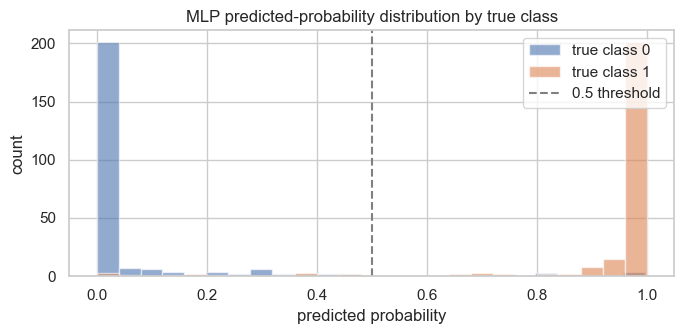

In [21]:
if HAS_TORCH:
    plt.figure(figsize=(7, 3.5))
    plt.hist(probs[y_te == 0], bins=25, alpha=0.6, label="true class 0")
    plt.hist(probs[y_te == 1], bins=25, alpha=0.6, label="true class 1")
    plt.axvline(0.5, ls="--", c="grey", label="0.5 threshold")
    plt.xlabel("predicted probability"); plt.ylabel("count")
    plt.title("MLP predicted-probability distribution by true class")
    plt.legend(); plt.tight_layout(); plt.show()

**Notice the API parity.** `BCEWithLogitsLoss` does sigmoid + binary cross-entropy in one numerically-stable operation. `AdamW` is the default optimiser for most deep-learning work today (Adam with decoupled weight decay). Three things to remember:

| Block | Replace with for… |
|---|---|
| `nn.BCEWithLogitsLoss` | binary classification |
| `nn.CrossEntropyLoss` | multi-class classification (no softmax in the model) |
| `nn.MSELoss` / `nn.L1Loss` | regression |


---

### ✋ Quick exercise (~2 min) — From logit to lead-conversion probability

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Your lead-scoring MLP (trained just like §7) outputs a single raw **logit = 1.5** for a new lead. (a) Which loss function did §7 use to *train* this binary classifier? (b) Convert the logit into a conversion **probability** the same way §7 does at inference.

```python
logit = torch.tensor(1.5)
```

In [22]:
# ✍️ Your turn 👇
if HAS_TORCH:
    logit = torch.tensor(1.5)
    # (a) which loss did §7 use to TRAIN this binary classifier?
    # (b) convert this single logit to a probability, exactly as §7 did at inference
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    logit = torch.tensor(1.5)
    prob = torch.sigmoid(logit)
    print(prob.item())          # ≈ 0.818
# Training loss: nn.BCEWithLogitsLoss — it fuses sigmoid + BCE in one
# numerically-stable step, so the model emits raw LOGITS, not probabilities.
```

In §7 the MLP is trained with `BCEWithLogitsLoss` (logits go straight in) and `torch.sigmoid` is applied **only at inference** to turn a logit into a probability. `sigmoid(1.5) ≈ 0.82`, i.e. an ~82% lead-conversion probability.
</details>

## 8. Saving and loading models

Two patterns. Use the second one in production.


In [23]:
if HAS_TORCH:
    # (a) Quick — pickle the whole model object (fragile; ties to your class definition)
    # torch.save(model, "model.pt")
    # model2 = torch.load("model.pt")

    # (b) Recommended — save just the state_dict (the weights), reconstruct the class separately:
    torch.save(model.state_dict(), "/tmp/tab_mlp_state.pt")
    model2 = TabularMLP(in_dim=Xtr.shape[1])
    model2.load_state_dict(torch.load("/tmp/tab_mlp_state.pt"))
    model2.eval()
    with torch.no_grad():
        same = torch.allclose(model(Xte), model2(Xte))
    print("reloaded model produces identical outputs:", same)


reloaded model produces identical outputs: True


## 9. The four bugs you will hit

| Symptom | Cause | Fix |
|---|---|---|
| **NaN loss after epoch 1** | LR too high, or `log(0)` in custom loss | Lower `lr`, use `BCEWithLogitsLoss` not raw `BCELoss` |
| **Loss is flat** | Gradients zero — wrong dtype, frozen layer, missing `requires_grad` | Print `param.grad.norm()` per layer |
| **Val loss < train loss** (suspicious) | Data leak; you're scaling using *all* X | Fit the scaler on train only |
| **CUDA out of memory** | Batch too big, or you forgot `with torch.no_grad()` in eval | Reduce batch, use `no_grad` for inference |

A surprising amount of debugging happens *before* training even starts — print shapes, dtypes, and parameter counts at construction time.


---
## 10. Regularisation — the three knobs that actually move the needle

A model that nails the training set but flunks the test set is **overfitting**. PyTorch gives you three reliable tools, in rough order of how often you'll reach for them:

| Knob | What it does | Where it lives |
|---|---|---|
| **Weight decay** ($L_2$) | Pulls weights toward 0 each step → smoother functions | `optimizer = torch.optim.AdamW(..., weight_decay=1e-2)` |
| **Dropout** | Randomly zeroes a fraction of activations *during training only* → forces redundancy | `nn.Dropout(p=0.2)` as a layer |
| **Early stopping** | Stop when validation loss stops improving | your training loop (see §12) |

Two traps worth burning into memory:

- **`AdamW` ≠ `Adam`.** Plain `Adam` couples weight decay to the gradient update and gets it subtly wrong. `AdamW` *decouples* it — it's the modern default. Use it.
- **Dropout is mode-sensitive.** It must be *on* in `model.train()` and *off* in `model.eval()`. Forgetting `model.eval()` at inference is one of the most common silent bugs — your predictions become noisy and non-deterministic.

In [24]:
if HAS_TORCH:
    torch.manual_seed(0)

    class RegularisedMLP(nn.Module):
        """Same idea as §4, now with dropout between layers."""
        def __init__(self, in_dim, hidden=64, p_drop=0.2):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(p_drop),
                nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p_drop),
                nn.Linear(hidden, 1),          # logits
            )
        def forward(self, x):
            return self.net(x).squeeze(-1)

In [25]:
if HAS_TORCH:
    model = RegularisedMLP(in_dim=8)

    # AdamW = Adam + *decoupled* weight decay. weight_decay is the L2 strength.
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

    # Watch dropout flip with the mode:
    x = torch.randn(4, 8)
    model.train(); a = model(x)         # dropout active  -> stochastic
    model.eval()
    with torch.no_grad():
        b1, b2 = model(x), model(x)     # dropout off     -> deterministic
    print("train() outputs vary run-to-run; eval() is stable:",
          torch.allclose(b1, b2))
    print("optimiser:", type(opt).__name__, "| weight_decay:", opt.defaults['weight_decay'])

train() outputs vary run-to-run; eval() is stable: True
optimiser: AdamW | weight_decay: 0.01


## 11. Learning-rate schedules — the single biggest free win

The learning rate is the most important hyper-parameter, and a **constant** LR leaves performance on the table. The modern recipe: start a touch higher, then **decay** as you approach the minimum. Three schedulers cover ~95% of cases:

- **`CosineAnnealingLR`** — smooth decay from `lr` to ≈0 over `T_max` epochs. The default-good choice.
- **`OneCycleLR`** — warm up *then* anneal within a single run; superb for short training budgets.
- **`ReduceLROnPlateau`** — cut the LR when *validation* loss stalls; reactive rather than scheduled.

Mechanics that trip people up: you call **`scheduler.step()` once per epoch** (except `OneCycleLR`, which steps **per batch**), and *after* `optimizer.step()`. `ReduceLROnPlateau.step(val_loss)` takes the metric as an argument.

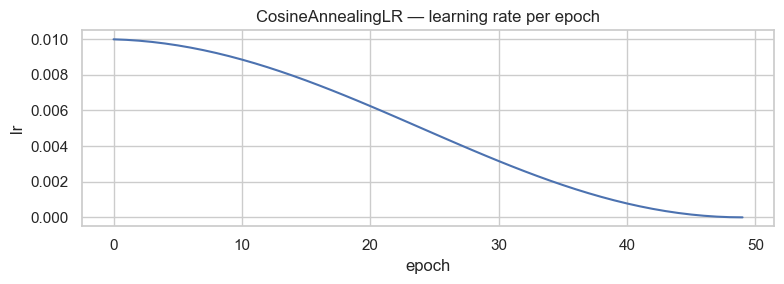

lr fell from 0.0100 to 0.000000


In [26]:
if HAS_TORCH:
    import math
    demo = nn.Linear(8, 1)
    opt = torch.optim.AdamW(demo.parameters(), lr=1e-2)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)

    lrs = []
    for epoch in range(50):
        opt.step()            # (no real grads here — just demoing the schedule)
        sched.step()
        lrs.append(opt.param_groups[0]["lr"])

    plt.figure(figsize=(8, 3))
    plt.plot(lrs)
    plt.title("CosineAnnealingLR — learning rate per epoch")
    plt.xlabel("epoch"); plt.ylabel("lr"); plt.tight_layout(); plt.show()
    print(f"lr fell from {lrs[0]:.4f} to {lrs[-1]:.6f}")
else:
    print("Skipped — torch not installed.")

---

### ✋ Quick exercise (~2 min) — Read the LR off a cosine schedule

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Attach a `CosineAnnealingLR` (with `T_max=10`) to an `AdamW` optimiser (`lr=0.1`) on a dummy `nn.Linear(4, 1)`. Step both the optimiser and the scheduler **5 times**, then print the *current* learning rate. Roughly where do you expect it to land?

```python
layer = nn.Linear(4, 1)
opt = torch.optim.AdamW(layer.parameters(), lr=0.1)
```

In [27]:
# ✍️ Your turn 👇
if HAS_TORCH:
    layer = nn.Linear(4, 1)
    opt = torch.optim.AdamW(layer.parameters(), lr=0.1)
    # build a CosineAnnealingLR with T_max=10, step opt+sched 5 times,
    # then read the current LR from opt.param_groups[0]["lr"]
else:
    print("PyTorch not available — skipping.")

<details>
<summary>✅ <b>Solution</b></summary>

```python
if HAS_TORCH:
    layer = nn.Linear(4, 1)
    opt = torch.optim.AdamW(layer.parameters(), lr=0.1)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=10)
    for _ in range(5):
        opt.step()            # would normally follow loss.backward()
        sched.step()          # once per epoch, AFTER optimizer.step()
    print(opt.param_groups[0]["lr"])   # ≈ 0.05 — cosine is halfway down
```

Cosine annealing decays smoothly from `lr` to ≈0 over `T_max` epochs. At step 5 of 10 you're halfway through the cosine curve, so the live LR — read from `opt.param_groups[0]["lr"]` — is about **0.05**.
</details>

## 12. A reusable `fit()` — validation, early stopping & history in one place

Copy-pasting the five-line loop is fine for a demo, but real work wants: a **train/val split**, `model.train()`/`model.eval()` toggling, an **LR scheduler**, **early stopping** on the best validation loss, and a **history** you can plot. Here is a compact, reusable trainer that you can lift straight into a project — it's the loop from §5 with the production hygiene wrapped around it.

In [28]:
if HAS_TORCH:
    from torch.utils.data import TensorDataset, DataLoader

    def fit(model, X_tr, y_tr, X_val, y_val, *, epochs=100, lr=1e-3,
            weight_decay=1e-2, batch_size=64, patience=10, device="cpu"):
        """Train with early stopping; return (best_state, history)."""
        model = model.to(device)
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        loss_fn = nn.BCEWithLogitsLoss()

        dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
        history = {"train": [], "val": []}
        best_val, best_state, bad_epochs = float("inf"), None, 0

        for epoch in range(epochs):
            model.train()
            run = 0.0
            for xb, yb in dl:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # tame exploding grads
                opt.step()
                run += loss.item() * len(xb)
            sched.step()

            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(X_val.to(device)), y_val.to(device)).item()
            history["train"].append(run / len(X_tr)); history["val"].append(val_loss)

            if val_loss < best_val - 1e-4:
                best_val, bad_epochs = val_loss, 0
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    print(f"Early stop @ epoch {epoch} (best val {best_val:.4f})")
                    break
        return best_state, history

In [29]:
if HAS_TORCH:
    # --- synthetic tabular demo so the cell runs standalone ---
    from sklearn.datasets import make_classification
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    Xn, yn = make_classification(n_samples=2000, n_features=8, n_informative=6, random_state=0)
    Xd_tr, Xd_va, yd_tr, yd_va = train_test_split(Xn, yn, test_size=0.25, random_state=0)
    sc = StandardScaler().fit(Xd_tr)
    to_t = lambda a: torch.tensor(sc.transform(a), dtype=torch.float32)
    Xd_tr_t, Xd_va_t = to_t(Xd_tr), to_t(Xd_va)
    yd_tr_t = torch.tensor(yd_tr, dtype=torch.float32); yd_va_t = torch.tensor(yd_va, dtype=torch.float32)

Early stop @ epoch 69 (best val 0.1568)


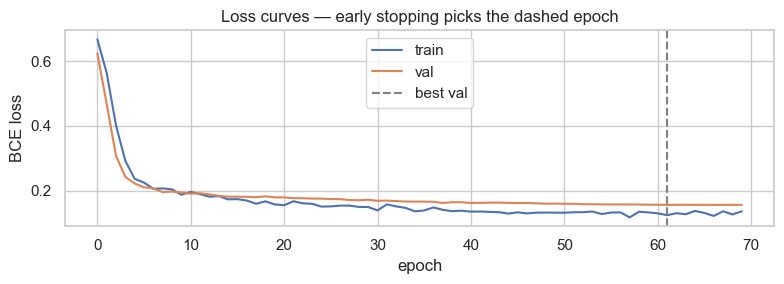

In [30]:
if HAS_TORCH:
    torch.manual_seed(0)
    best_state, hist = fit(RegularisedMLP(8), Xd_tr_t, yd_tr_t, Xd_va_t, yd_va_t, epochs=80, patience=8)

    plt.figure(figsize=(8, 3))
    plt.plot(hist["train"], label="train"); plt.plot(hist["val"], label="val")
    plt.axvline(int(np.argmin(hist["val"])), ls="--", c="grey", label="best val")
    plt.legend(); plt.title("Loss curves — early stopping picks the dashed epoch")
    plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.tight_layout(); plt.show()

**Read the curves, not the final number.** When `val` turns up while `train` keeps falling, you're memorising. Early stopping reloads `best_state` (the dashed epoch) — so always restore it before you score the test set:

```python
model.load_state_dict(best_state)   # roll back to the best validation checkpoint
```

## 13. Reproducibility & device-agnostic code

Two boilerplate helpers that belong at the top of every PyTorch project. The first makes runs repeatable (essential for debugging — *was it my change or just a new random seed?*); the second runs the same code unchanged on CPU, CUDA, or Apple-Silicon MPS.

In [31]:
if HAS_TORCH:
    import random

    def seed_everything(seed=42):
        random.seed(seed); np.random.seed(seed)
        torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
        # For full determinism (slower): torch.use_deterministic_algorithms(True)

    def pick_device():
        if torch.cuda.is_available():
            return torch.device("cuda")
        if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
            return torch.device("mps")        # Apple Silicon
        return torch.device("cpu")

    seed_everything(42)
    device = pick_device()
    print("Using device:", device)
    # Pass device=pick_device() into fit() and every .to(device) call inside
    # routes tensors there — no other code change needed. (The §12 demo used
    # the default device="cpu", which is why it runs the same on any machine.)
else:
    print("Skipped — torch not installed.")

Using device: mps


## 🧪 Exercises

### Exercise 1 — Add early stopping
The training loop above runs a fixed number of epochs. Add **early stopping** on the validation loss: track the best val loss so far, stop if it doesn't improve for `patience=5` epochs, and restore the best weights at the end.


In [32]:
if HAS_TORCH:
    # ── Exercise 1 solution ──────────────────────────────────────────────
    import copy
    def train_with_early_stop(dl_tr, X_va, y_va, in_dim, max_epochs=100, patience=5, lr=3e-3):
        model = TabularMLP(in_dim=in_dim)
        opt   = torch.optim.AdamW(model.parameters(), lr=lr)
        loss_fn = nn.BCEWithLogitsLoss()
        best_state, best_va, wait = None, float("inf"), 0
        for epoch in range(max_epochs):
            model.train()
            for xb, yb in dl_tr:
                opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
            model.eval()
            with torch.no_grad():
                va = loss_fn(model(X_va), y_va).item()
            if va < best_va - 1e-4:
                best_va, best_state, wait = va, copy.deepcopy(model.state_dict()), 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"stopping at epoch {epoch}; best val loss = {best_va:.4f}")
                    break
        model.load_state_dict(best_state)
        return model, best_va

    # Early stopping is a *tuning* decision, so it must watch a VALIDATION
    # slice carved out of the training data — never the test set.
    n_va = len(Xtr) // 5
    Xva, yva = Xtr[:n_va], ytr[:n_va]                 # rows are already shuffled
    dl = DataLoader(TensorDataset(Xtr[n_va:], ytr[n_va:]), batch_size=64, shuffle=True)
    best_model, best_va = train_with_early_stop(dl, Xva, yva, in_dim=Xtr.shape[1])

    # Only now, with the checkpoint frozen, does the untouched test set get scored:
    best_model.eval()
    with torch.no_grad():
        p_es = torch.sigmoid(best_model(Xte)).squeeze().numpy()
    print(f"early-stopped model · test AUC = {roc_auc_score(y_te, p_es):.3f}")


stopping at epoch 36; best val loss = 0.1458
early-stopped model · test AUC = 0.980


### Exercise 2 — Compare to a much smaller MLP
Train a tiny MLP (one hidden layer with 8 units, no dropout). On this dataset, do you get a better or worse AUC than the 2-hidden-layer MLP? What does that tell you about *model capacity* vs *dataset size*?


In [33]:
if HAS_TORCH:
    # ── Exercise 2 solution ──────────────────────────────────────────────
    class TinyMLP(nn.Module):
        def __init__(self, in_dim):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(in_dim, 8), nn.ReLU(), nn.Linear(8, 1))
        def forward(self, x): return self.net(x)

    m = TinyMLP(Xtr.shape[1])
    opt = torch.optim.AdamW(m.parameters(), lr=3e-3, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss()
    for epoch in range(60):
        m.train()
        for xb, yb in dl_tr:
            opt.zero_grad(); loss_fn(m(xb), yb).backward(); opt.step()
    m.eval()
    with torch.no_grad():
        probs = torch.sigmoid(m(Xte)).squeeze().numpy()
    print(f"Tiny MLP   ·  AUC={roc_auc_score(y_te, probs):.3f}")
    # Comment: worse — the tiny net UNDERFITS here, landing a few AUC points
    # below the 2-hidden-layer MLP from §7. With 2000 rows and 10 informative
    # features there is enough signal to reward the bigger model's capacity.
    # The lesson cuts both ways: capacity has to match the dataset — too little
    # underfits (this cell), too much overfits (that's what dropout, weight
    # decay and early stopping were guarding against).


Tiny MLP   ·  AUC=0.963


## 🧠 Key takeaways

- Tensors + autograd + `nn.Module` + an optimiser = everything you need.
- The training loop is **always** the same five lines: forward → loss → `zero_grad` → `backward` → `step`.
- Use `BCEWithLogitsLoss`/`CrossEntropyLoss`/`MSELoss` — not their numerically-unstable cousins.
- Save the **state_dict**, not the whole model object.
- Most bugs are detected by *printing shapes & gradients* before you blame the math.

## 🚀 Next step

[`A2_pytorch_vision_and_sequences.ipynb`](./A2_pytorch_vision_and_sequences.ipynb) — CNNs for images, RNNs and a small Transformer for sequences.
